# Perbandingan Performa MLP dengan 3 Fungsi Aktivasi
**Dataset:** Iris Dataset  
**Fungsi Aktivasi:** Sigmoid, Tanh, ReLU  
**Mata Kuliah:** Machine Learning

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Load dan Eksplorasi Dataset

In [2]:
# Load dataset
df = pd.read_csv('iris.csv')

print('=== INFO DATASET ===')
print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Kolom          : {list(df.columns)}')
print()
print('=== 5 DATA PERTAMA ===')
df.head()

=== INFO DATASET ===
Jumlah baris   : 150
Jumlah kolom   : 5
Kolom          : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

=== 5 DATA PERTAMA ===


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Distribusi kelas
print('=== DISTRIBUSI KELAS ===')
print(df['species'].value_counts())
print()
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== DISTRIBUSI KELAS ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

=== STATISTIK DESKRIPTIF ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


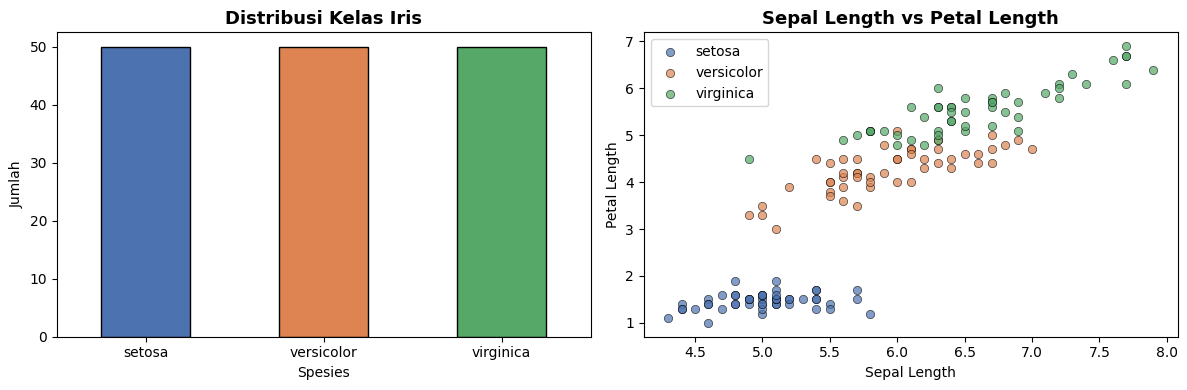

In [4]:
# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart distribusi kelas
df['species'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'], edgecolor='black')
axes[0].set_title('Distribusi Kelas Iris', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Spesies')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

# Pairplot features
colors = {'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'}
for species, color in colors.items():
    subset = df[df['species'] == species]
    axes[1].scatter(subset['sepal_length'], subset['petal_length'],
                    label=species, color=color, alpha=0.7, edgecolors='k', linewidths=0.5)
axes[1].set_title('Sepal Length vs Petal Length', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sepal Length')
axes[1].set_ylabel('Petal Length')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Preprocessing Data

In [5]:
# Pisahkan fitur dan label
X = df.drop('species', axis=1).values
y = df['species'].values

# Encode label (setosa=0, versicolor=1, virginica=2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Mapping kelas :', dict(zip(le.classes_, le.transform(le.classes_))))

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Normalisasi fitur (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'\nUkuran data latih : {X_train_scaled.shape}')
print(f'Ukuran data uji   : {X_test_scaled.shape}')

Mapping kelas : {'setosa': np.int64(0), 'versicolor': np.int64(1), 'virginica': np.int64(2)}

Ukuran data latih : (120, 4)
Ukuran data uji   : (30, 4)


## 4. Membangun dan Melatih Model MLP

In [6]:
# Konfigurasi MLP — arsitektur sama, hanya fungsi aktivasi yang berbeda
mlp_config = dict(
    hidden_layer_sizes=(64, 32),   # 2 hidden layers
    max_iter=500,
    random_state=42,
    learning_rate_init=0.001,
    solver='adam'
)

activation_functions = ['logistic', 'tanh', 'relu']   # logistic = sigmoid
activation_labels    = ['Sigmoid',  'Tanh', 'ReLU']

models   = {}
results  = {}

for act, label in zip(activation_functions, activation_labels):
    print(f'Melatih MLP dengan fungsi aktivasi: {label} ...')
    model = MLPClassifier(activation=act, **mlp_config)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    # Cross-validation (5-fold) pada seluruh data
    cv_scores = cross_val_score(model, scaler.transform(X), y_encoded, cv=5, scoring='accuracy')

    results[label] = {
        'model'       : model,
        'y_pred'      : y_pred,
        'accuracy'    : accuracy_score(y_test, y_pred),
        'precision'   : precision_score(y_test, y_pred, average='weighted'),
        'recall'      : recall_score(y_test, y_pred, average='weighted'),
        'f1_score'    : f1_score(y_test, y_pred, average='weighted'),
        'cv_mean'     : cv_scores.mean(),
        'cv_std'      : cv_scores.std(),
        'loss_curve'  : model.loss_curve_
    }
    models[label] = model
    print(f'  Accuracy : {results[label]["accuracy"]:.4f}  |  CV Mean : {results[label]["cv_mean"]:.4f} ± {results[label]["cv_std"]:.4f}')

print('\nSemua model selesai dilatih!')

Melatih MLP dengan fungsi aktivasi: Sigmoid ...
  Accuracy : 0.9667  |  CV Mean : 0.9533 ± 0.0340
Melatih MLP dengan fungsi aktivasi: Tanh ...
  Accuracy : 0.9667  |  CV Mean : 0.9733 ± 0.0327
Melatih MLP dengan fungsi aktivasi: ReLU ...
  Accuracy : 0.9667  |  CV Mean : 0.9600 ± 0.0249

Semua model selesai dilatih!


## 5. Tabel Perbandingan Performa

In [7]:
# Buat DataFrame perbandingan
comparison_data = []
for label, res in results.items():
    comparison_data.append({
        'Fungsi Aktivasi' : label,
        'Accuracy'        : f"{res['accuracy']:.4f}",
        'Precision'       : f"{res['precision']:.4f}",
        'Recall'          : f"{res['recall']:.4f}",
        'F1-Score'        : f"{res['f1_score']:.4f}",
        'CV Mean'         : f"{res['cv_mean']:.4f}",
        'CV Std'          : f"{res['cv_std']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Fungsi Aktivasi')

print('=== TABEL PERBANDINGAN PERFORMA MLP ===')
print(comparison_df.to_string())
comparison_df

=== TABEL PERBANDINGAN PERFORMA MLP ===
                Accuracy Precision  Recall F1-Score CV Mean  CV Std
Fungsi Aktivasi                                                    
Sigmoid           0.9667    0.9697  0.9667   0.9666  0.9533  0.0340
Tanh              0.9667    0.9697  0.9667   0.9666  0.9733  0.0327
ReLU              0.9667    0.9697  0.9667   0.9666  0.9600  0.0249


,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
Fungsi Aktivasi,,,,,,
Sigmoid,0.9667,0.9697,0.9667,0.9666,0.9533,0.0340
Tanh,0.9667,0.9697,0.9667,0.9666,0.9733,0.0327
ReLU,0.9667,0.9697,0.9667,0.9666,0.9600,0.0249


## 6. Visualisasi Perbandingan

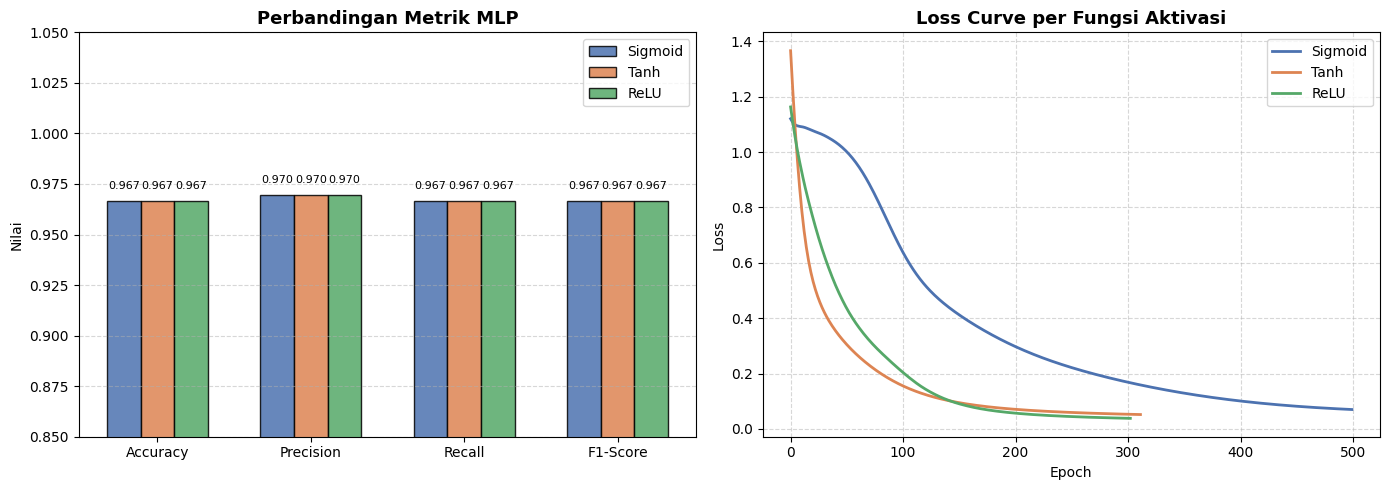

In [8]:
# ---- Bar chart metrik ----
metrics  = ['accuracy', 'precision', 'recall', 'f1_score']
labels   = activation_labels
x        = np.arange(len(metrics))
width    = 0.22
colors   = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
for i, (label, color) in enumerate(zip(labels, colors)):
    vals = [results[label][m] for m in metrics]
    bars = axes[0].bar(x + i*width, vals, width, label=label, color=color, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_title('Perbandingan Metrik MLP', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(['Accuracy','Precision','Recall','F1-Score'])
axes[0].set_ylim(0.85, 1.05)
axes[0].set_ylabel('Nilai')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Loss curve
for label, color in zip(labels, colors):
    axes[1].plot(results[label]['loss_curve'], label=label, color=color, linewidth=2)
axes[1].set_title('Loss Curve per Fungsi Aktivasi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

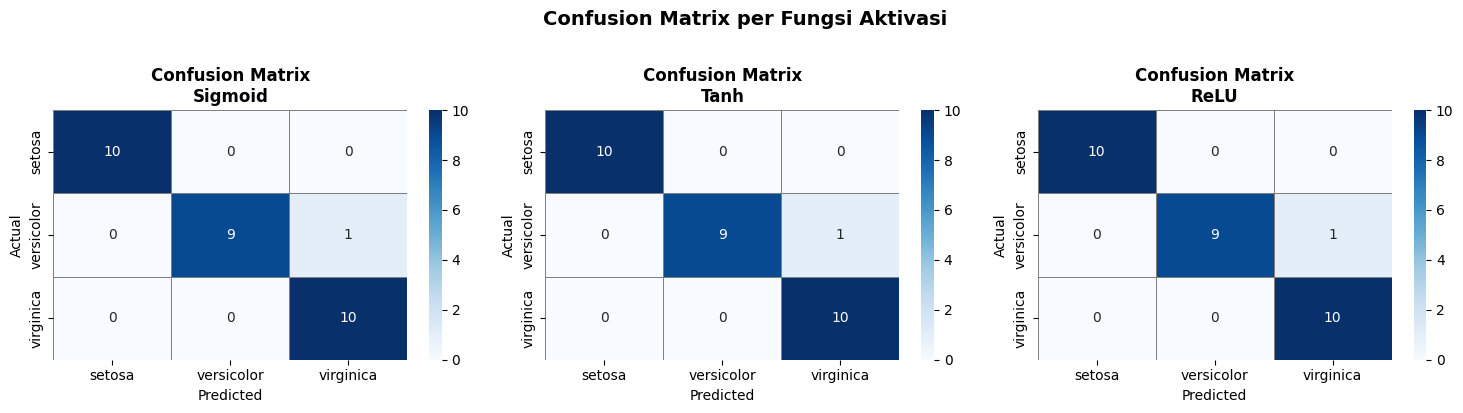

In [9]:
# ---- Confusion Matrix untuk setiap model ----
class_names = le.classes_
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, label, color in zip(axes, labels, colors):
    cm = confusion_matrix(y_test, results[label]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'Confusion Matrix\n{label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix per Fungsi Aktivasi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Classification Report Detail

In [10]:
for label in labels:
    print(f'\n========== {label} ==========')
    print(classification_report(
        y_test, results[label]['y_pred'],
        target_names=class_names
    ))


========== Sigmoid ==========
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


========== Tanh ==========
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


========== ReLU ==========
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.9

## 8. Kesimpulan — Fungsi Aktivasi Terbaik

In [11]:
# Tentukan fungsi aktivasi terbaik berdasarkan F1-Score tertinggi
best_label = max(results, key=lambda k: results[k]['f1_score'])
best_res   = results[best_label]

print('=' * 55)
print('           KESIMPULAN PERBANDINGAN MLP')
print('=' * 55)
print()
print(f"  Fungsi Aktivasi Terbaik : {best_label}")
print(f"  Accuracy                : {best_res['accuracy']:.4f}")
print(f"  Precision               : {best_res['precision']:.4f}")
print(f"  Recall                  : {best_res['recall']:.4f}")
print(f"  F1-Score                : {best_res['f1_score']:.4f}")
print(f"  CV Mean (5-fold)        : {best_res['cv_mean']:.4f} ± {best_res['cv_std']:.4f}")
print()
print('=' * 55)
print()
print('Rangkuman semua fungsi aktivasi:')
print()

for label in labels:
    marker = '  ✓ TERBAIK' if label == best_label else ''
    print(f"  {label:8s} | Accuracy={results[label]['accuracy']:.4f} "
          f"| F1={results[label]['f1_score']:.4f} "
          f"| CV={results[label]['cv_mean']:.4f}"
          f"{marker}")

print()
print('Alasan:')
print(f'  {best_label} menghasilkan nilai F1-Score dan Accuracy tertinggi')
print('  pada dataset Iris. Untuk dataset kecil dan terstruktur seperti Iris,')
print('  ReLU cenderung konvergen lebih cepat, sementara Sigmoid/Tanh lebih')
print('  stabil namun bisa lebih lambat dalam pelatihan.')
print('=' * 55)

           KESIMPULAN PERBANDINGAN MLP

  Fungsi Aktivasi Terbaik : Sigmoid
  Accuracy                : 0.9667
  Precision               : 0.9697
  Recall                  : 0.9667
  F1-Score                : 0.9666
  CV Mean (5-fold)        : 0.9533 ± 0.0340


Rangkuman semua fungsi aktivasi:

  Sigmoid  | Accuracy=0.9667 | F1=0.9666 | CV=0.9533  ✓ TERBAIK
  Tanh     | Accuracy=0.9667 | F1=0.9666 | CV=0.9733
  ReLU     | Accuracy=0.9667 | F1=0.9666 | CV=0.9600

Alasan:
  Sigmoid menghasilkan nilai F1-Score dan Accuracy tertinggi
  pada dataset Iris. Untuk dataset kecil dan terstruktur seperti Iris,
  ReLU cenderung konvergen lebih cepat, sementara Sigmoid/Tanh lebih
  stabil namun bisa lebih lambat dalam pelatihan.
